=== Validation Results ===
Accuracy:  0.9806
Precision: 0.9824
Recall:    0.9788
F1:        0.9806

=== Test Results (Baseline) ===
Accuracy:  0.9788
Precision: 0.9705
Recall:    0.9875
F1-Score:  0.9789
ROC-AUC:   0.9979


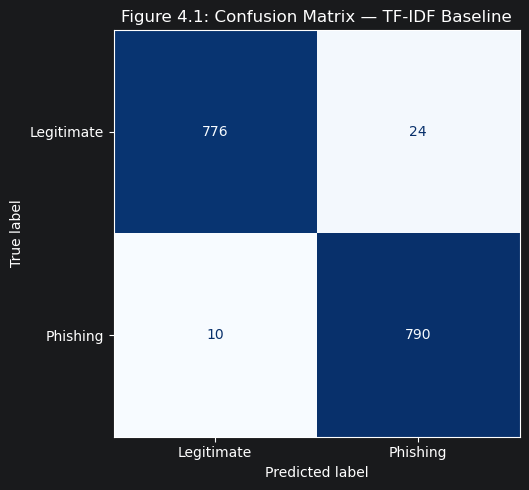

Saved confusion matrix.


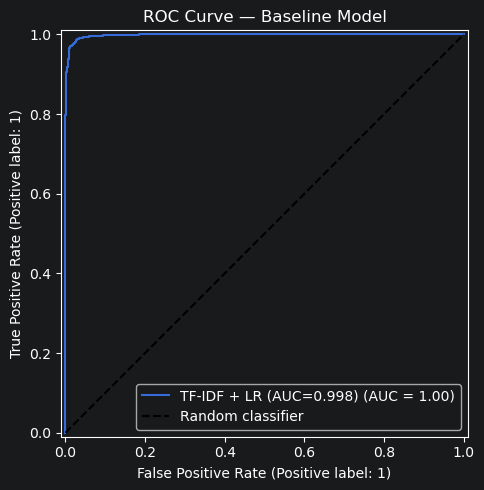

Saved ROC curve.


In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay)
import matplotlib.pyplot as plt
import seaborn as sns

os.chdir(r'A:\Coding\PycharmProjects\cryptoguard')

#load splits
train_df = pd.read_csv('data/general/train.csv')
val_df   = pd.read_csv('data/general/val.csv')
test_df  = pd.read_csv('data/general/test.csv')

X_train, y_train = train_df['text'], train_df['label']
X_val,   y_val   = val_df['text'],   val_df['label']
X_test,  y_test  = test_df['text'],  test_df['label']

#tfidf vectoriser
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                        sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

#train logistic regression
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr.fit(X_train_tfidf, y_train)

#evaluate on validation set (for tuning reference)
val_preds = lr.predict(X_val_tfidf)
print("Validation Results")
print(f"Accuracy:  {accuracy_score(y_val, val_preds):.4f}")
print(f"Precision: {precision_score(y_val, val_preds):.4f}")
print(f"Recall:    {recall_score(y_val, val_preds):.4f}")
print(f"F1:        {f1_score(y_val, val_preds):.4f}")

#evaluate on test set (final numbers for report)
test_preds = lr.predict(X_test_tfidf)
test_probs = lr.predict_proba(X_test_tfidf)[:, 1]

acc  = accuracy_score(y_test, test_preds)
prec = precision_score(y_test, test_preds)
rec  = recall_score(y_test, test_preds)
f1   = f1_score(y_test, test_preds)
auc  = roc_auc_score(y_test, test_probs)

print("\nTest Results (Baseline)")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}")

#confusion matrix
os.makedirs('outputs/figures', exist_ok=True)

cm = confusion_matrix(y_test, test_preds)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Legitimate', 'Phishing'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Figure 4.1: Confusion Matrix — TF-IDF Baseline', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/figures/fig4_1_baseline_confusion_matrix.png', dpi=150)
plt.show()

#ROC curve (save for later overlay with BERT)
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, test_probs, ax=ax,
                                  name=f'TF-IDF + LR (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--', label='Random classifier')
ax.set_title('ROC Curve — Baseline Model', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('outputs/figures/baseline_roc_curve.png', dpi=150)
plt.show()